In [ ]:
%pip install neo4j networkx python-dotenv --no-cache-dir

In [ ]:
%pip install Faker

In [ ]:
from neo4j import GraphDatabase
import networkx as nx
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

False

In [2]:
# Use volume to load .env to jupyter!!
load_dotenv()

True

In [29]:
from __future__ import annotations
from faker import Faker
from random import choices
fake = Faker()


class Person: 
    def __init__(
            self, 
            name: str, 
            age: int, 
            city: str, 
            email: str, 
            friend_of: set[Person]=None
    ):
        self.name = name
        self.age = age
        self.city = city
        self.email = email
        self.friend_of = friend_of or set()
    
    def __repr__(self):
        return f"Name: {self.name}, Age: {self.age}, City: {self.city}, friends: {', '.join([f.name for f in self.friend_of])}"

class People:
    def __init__(self):
        self.people: list[Person] = []
    
    def append(self, person: Person):
        self.people.append(person)
    
    def get_any_other(self, person: Person):
        return choices(list(filter(lambda p: p is not person, self.people)))

    def start_association(self):
        for p in self.people:
            other = self.get_any_other(p)[0]
            p.friend_of.add(other)
            other.friend_of.add(p)

people = People()
for _ in range(35):
    people.append(Person(fake.name(), fake.random_int(min=18, max=120), fake.city(), fake.unique.email()))

people.start_association()

for p in people.people:
    # don't befriend self check
    assert p not in p.friend_of, f"{p.name} is friend with self"

In [30]:
# use container ip for local test (default bridge network)
driver = GraphDatabase.driver(
    "bolt://172.17.0.2:7687", auth=(os.getenv("NEO4J_USER"), os.getenv("NEO4J_PW"))
)

In [31]:
def create_person(tx, person: Person):
    tx.run(
        """
        MERGE (p: Person {email: $email})
        SET p.name = $name,
            p.age = $age,
            p.city = $city
        """,
        email=person.email,
        name=person.name,
        age=person.age,
        city=person.city
    )

def create_friendship(tx, person: Person, friend: Person):
    if person.email == friend.email:
        return
    tx.run(
        """
        MATCH (a:Person {email: $email1})
        MATCH (b:Person {email: $email2})
        WHERE a <> b
        MERGE (a)-[:FRIEND_OF]->(b)
        """,
        email1=person.email,
        email2=friend.email # names are unique but still
    )

In [32]:
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n;")
    for p in people.people:
        session.execute_write(create_person, p)
    for p in people.people:
        for friend in p.friend_of:
            session.execute_write(create_friendship, p, friend)

In [33]:
emails = [p.email for p in people.people]
print("total emails:", len(emails))
print("unique emails:", len(set(emails)))

total emails: 35
unique emails: 35


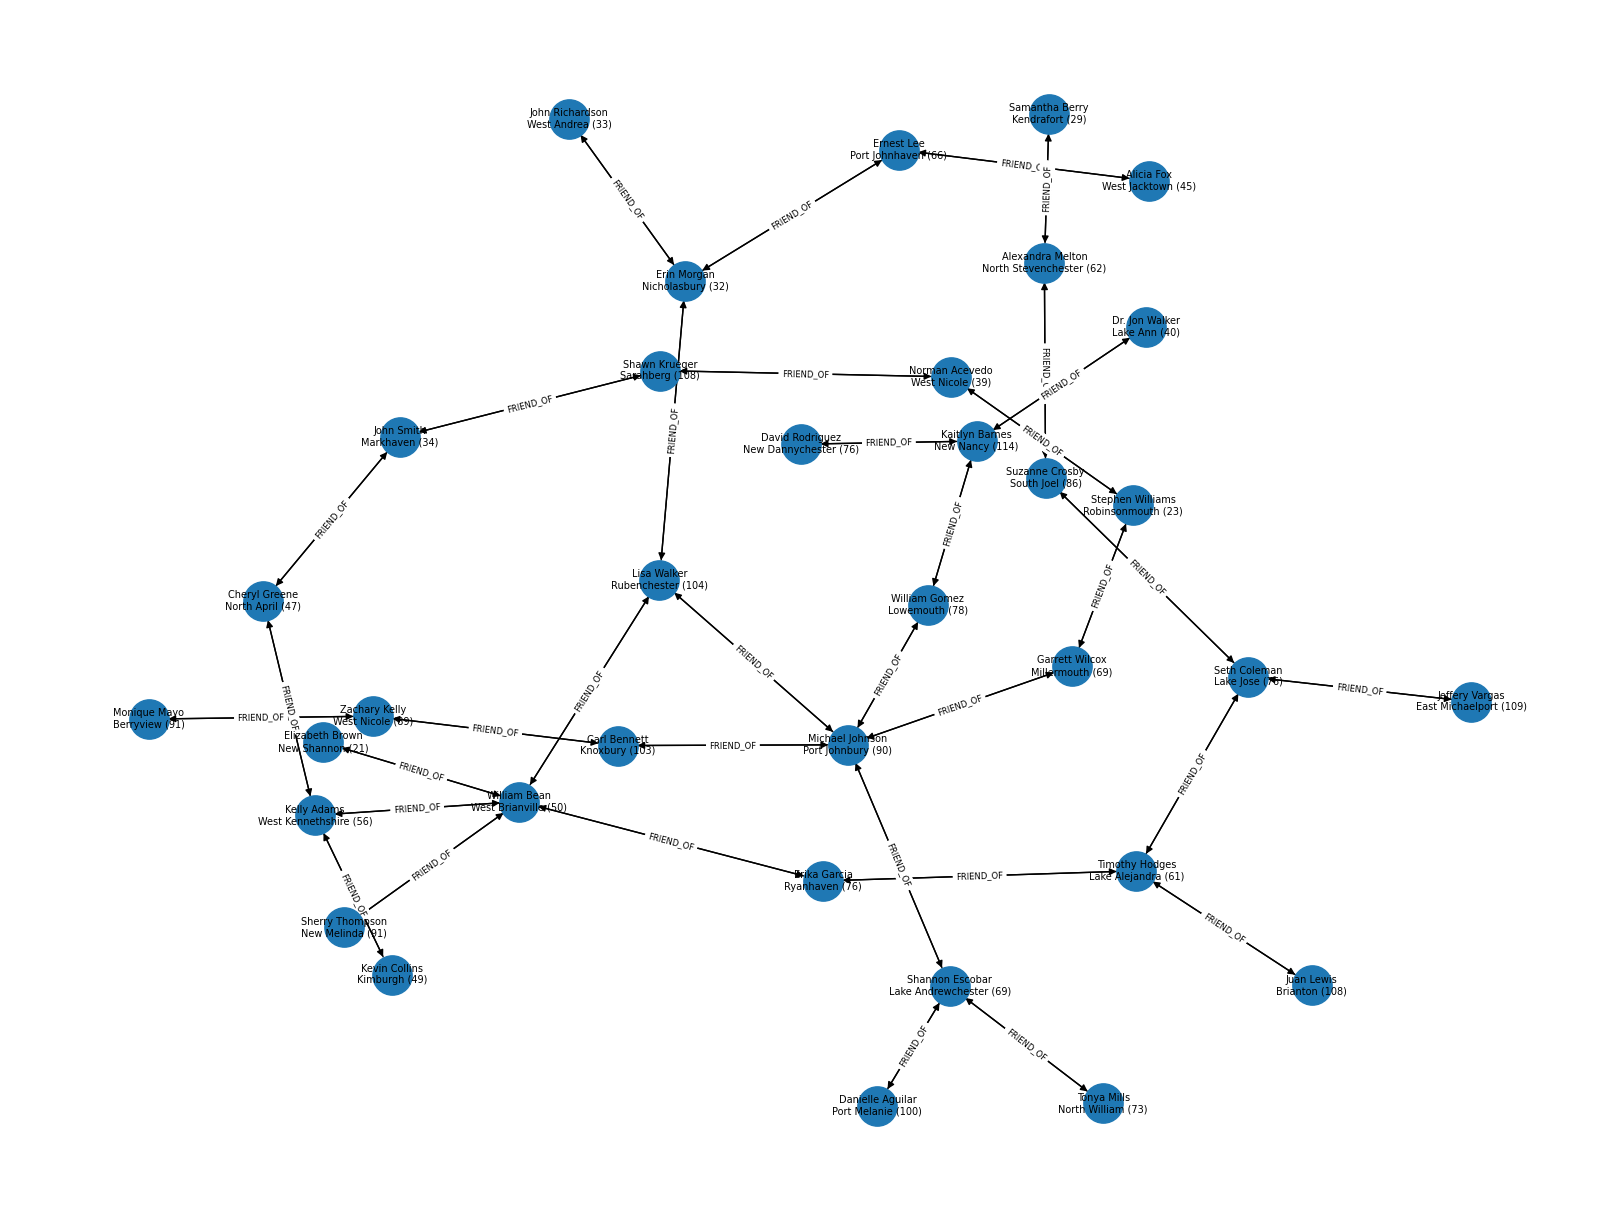

In [34]:
with driver.session() as s:
    q = """
    MATCH (a:Person)-[r:FRIEND_OF]->(b:Person)
    RETURN a.email AS aId, properties(a) AS aProps,
           b.email AS bId, properties(b) AS bProps,
           type(r) AS relType
    """
    result = s.run(q)

    G = nx.DiGraph()

    for rec in result:
        a_id = rec["aId"]
        b_id = rec["bId"]

        G.add_node(a_id, **rec["aProps"])
        G.add_node(b_id, **rec["bProps"])

        # avoid duplicate edges
        if not G.has_edge(a_id, b_id):
            G.add_edge(a_id, b_id, rel=rec["relType"])

# cleaner labels
node_labels = {
    n: f"{d.get('name','')}\n{d.get('city','')} ({d.get('age','')})"
    for n, d in G.nodes(data=True)
}

edge_labels = {
    (u, v): d["rel"] for u, v, d in G.edges(data=True)
}

# draw
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=1.5, iterations=200, seed=42)
nx.draw(G, pos, with_labels=False, node_size=800)
nx.draw_networkx_labels(G, pos, node_labels, font_size=7)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

In [ ]:
driver.close()